<a href="https://colab.research.google.com/github/Harsh374/Elevate-Labs-Task-5/blob/main/Elevate_Labs_Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 5: Decision Trees and Random Forests**

*   Objective: Learn tree-based models for classification & regression.
*   Tools:  Scikit-learn, Graphviz
*   Dataset: Heart Disease Dataset
*   What You'll Learn : Decision trees, ensemble learning, feature importance.





Import Libraries

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
import graphviz

Load the dataset

In [26]:
file_path = '/content/heart.csv'
df = pd.read_csv(file_path)

Display basic info and first few rows

In [27]:
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


(None,
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
 0   52    1   0       125   212    0        1      168      0      1.0      2   
 1   53    1   0       140   203    1        0      155      1      3.1      0   
 2   70    1   0       145   174    0        1      125      1      2.6      0   
 3   61    1   0       148   203    0        1      161      0      0.0      2   
 4   62    0   0       138   294    1        1      106      0      1.9      1   
 
    ca  thal  target  
 0   2     3       0  
 1   0     3       0  
 2   0     3       0  
 3   1     3       0  
 4   3     2       0  )

*  The Heart Disease dataset has 1,025 entries and 14 columns.
*  The target column is the label (0 = no heart disease, 1 = heart disease), while the other columns are features like age, sex, cholesterol, etc.

Missing values and basic statistics

In [28]:
missing_values = df.isnull().sum()
summary_stats = df.describe()

missing_values, summary_stats

(age         0
 sex         0
 cp          0
 trestbps    0
 chol        0
 fbs         0
 restecg     0
 thalach     0
 exang       0
 oldpeak     0
 slope       0
 ca          0
 thal        0
 target      0
 dtype: int64,
                age          sex           cp     trestbps        chol  \
 count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
 mean     54.434146     0.695610     0.942439   131.611707   246.00000   
 std       9.072290     0.460373     1.029641    17.516718    51.59251   
 min      29.000000     0.000000     0.000000    94.000000   126.00000   
 25%      48.000000     0.000000     0.000000   120.000000   211.00000   
 50%      56.000000     1.000000     1.000000   130.000000   240.00000   
 75%      61.000000     1.000000     2.000000   140.000000   275.00000   
 max      77.000000     1.000000     3.000000   200.000000   564.00000   
 
                fbs      restecg      thalach        exang      oldpeak  \
 count  1025.000000  1025.000000

Here's what we've found:

*  No missing values: All columns are fully populated.
*  Statistical Summary: No obvious outliers, but some variables like chol and oldpeak have a wide range, which could affect training.
*  Categorical features: Columns like sex, cp, fbs, restecg, exang, slope, ca, and thal are categorical or ordinal.

Separate features and target

In [29]:
X = df.drop("target", axis=1)
y = df["target"]

Identify categorical features that need encoding

In [30]:
categorical_cols = ["cp", "restecg", "slope", "thal"]  # nominal or ordinal

One-hot encode categorical features

In [31]:
X_encoded = pd.get_dummies(X, columns=categorical_cols)

Train-test split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)

Optional: feature scaling (though not necessary for tree models)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_train_scaled.shape, y_train.shape

((820, 23), (820, 23), (820,))

Preprocessing is complete:
*  One-hot encoded categorical variables (cp, restecg, slope, thal)
*  Performed a stratified train-test split (80% train, 20% test)
*  Scaled the features (optional, but done for consistency)


*   The dataset now has 23 features after encoding.



 Train Decision Tree

In [34]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Predict and evaluate

In [35]:
y_pred = dtree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

Visualize the tree

In [36]:
dot_data = export_graphviz(
    dtree,
    out_file=None,
    feature_names=X_train.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)

accuracy, graph

(0.9853658536585366, <graphviz.sources.Source at 0x7aa63f973c10>)

Decision Tree Classifier Results:
1. Accuracy on test data: 98.54%
*  This is a very high score — it may indicate overfitting, especially if the tree is very deep.
2. Tree visualization: The graph object you received (<graphviz.sources.Source>) contains the full tree.
*  You can render it with:

In [37]:
graph.render("decision_tree")  # saves as PDF or image
graph.view()

'decision_tree.pdf'

In [38]:
print("Train Accuracy:", accuracy_score(y_train, dtree.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9853658536585366


Prune the Decision Tree

In [39]:
from sklearn.model_selection import GridSearchCV

params = {'max_depth': range(1, 20)}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5)
grid.fit(X_train, y_train)

print(f"Best depth: {grid.best_params_['max_depth']}")
print(f"Validation Accuracy: {grid.best_score_:.4f}")

Best depth: 12
Validation Accuracy: 0.9866


Pruned Decision Tree Summary:


*  Best Depth: 12

*  Cross-Validation Accuracy: 98.66% (very strong!)
*  This means: A tree depth of 12 generalizes better than a fully grown tree. It likely reduces overfitting while keeping excellent performance.


In [41]:
# Evaluate on test data
pruned_tree = grid.best_estimator_
y_test_pred = pruned_tree.predict(X_test)

from sklearn.metrics import accuracy_score
print("Test Accuracy (Pruned Tree):", accuracy_score(y_test, y_test_pred))


Test Accuracy (Pruned Tree): 0.9853658536585366


Train a Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


Feature Importances

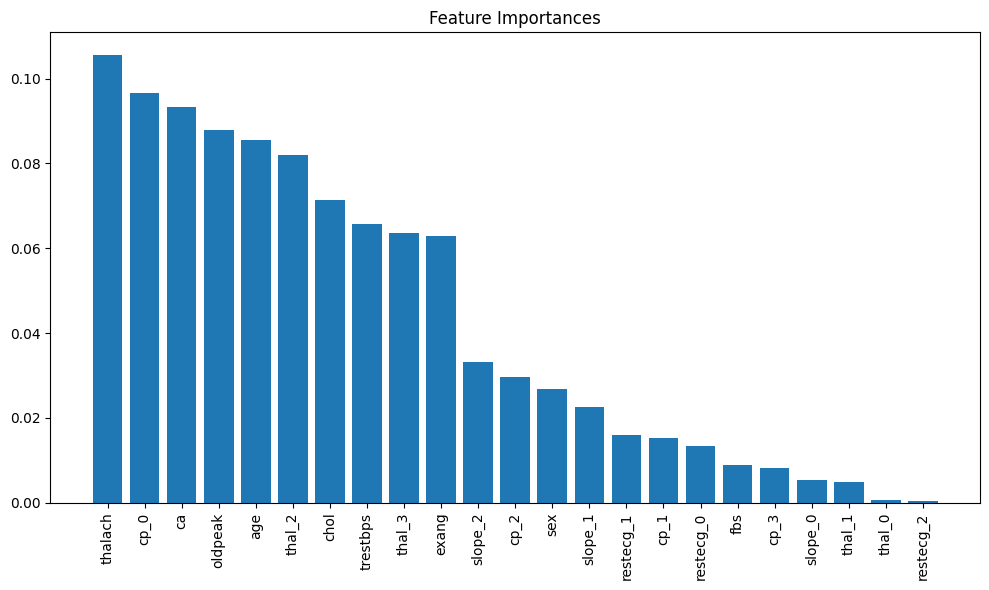

In [43]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X_train.columns
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()

Cross-Validation Accuracy

In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_encoded, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Average CV accuracy:", cv_scores.mean())

Cross-validation scores: [1.         1.         1.         1.         0.98536585]
Average CV accuracy: 0.9970731707317073
